In [1]:
"""
1. tensors
2. loss function + optimizer
3. training loop
4. fit the data + prediction
5. evaluate the model
6. improve = experimentation
7. save + reload trained model
------------------------------------
1. train + test separation , cleaning , data augmentation
2. layers + sizes + activition functions + optimizer + loss fct + training loop 
3. evaluate on validation set
4. make necessary adjustments (change optimizer, add regularization, adjust lr, retrain model)
5. save trained model
--------------------------------------------------------------
LOOP
1. pass data through epochs
2. pass data through model
3. perform forward
4. calculate loss
5. zero optimizer gradients
6. backpropagation
7. step the optimizer - loss.backward()
---------------------------------------------------------------
PROBLEM TYPE
1. binary classification
2. multiclass classification
3. object detection
4. segmentation
-------------------------------------------------------
"""

'\n1. tensors\n2. loss function + optimizer\n3. training loop\n4. fit the data + prediction\n5. evaluate the model\n6. improve = experimentation\n7. save + reload trained model\n------------------------------------\n1. train + test separation , cleaning , data augmentation\n2. layers + sizes + activition functions + optimizer + loss fct + training loop \n3. evaluate on validation set\n4. make necessary adjustments (change optimizer, add regularization, adjust lr, retrain model)\n5. save trained model\n--------------------------------------------------------------\nLOOP\n1. pass data through epochs\n2. pass data through model\n3. perform forward\n4. calculate loss\n5. zero optimizer gradients\n6. backpropagation\n7. step the optimizer - loss.backward()\n---------------------------------------------------------------\nPROBLEM TYPE\n1. binary classification\n2. multiclass classification\n3. object detection\n4. segmentation\n-------------------------------------------------------\n'

In [2]:
# Import PyTorch and matplotlib
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cpu'

In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [4]:
x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y = torch.tensor([[0], [0], [0], [1]], dtype=torch.float32)

In [5]:
if x.shape[0] == y.shape[0]:
    print("The shapes of our data match !")

The shapes of our data match !


In [6]:
class Perceptron(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Perceptron, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim) # takes in {input_dim}  features (X), produces {output_dim} features
        self.activation = torch.nn.Sigmoid()
        
    def forward(self, x):
        # x = self.linear(x)
        # x = self.activation(x)
        ## The upper line and lower are equivalent
        x =self.activation(self.linear(x)) #Takes in the computation through the linear layer and the resulting features of the linear layer through the activation
        return x

In [7]:
# Example usage:
model = Perceptron(2, 1)

In [8]:
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

In [9]:
num_epochs = 4000
loss_values = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    # Print the loss every 100 epochs
    loss_values.append(loss.item()) # This is so that we can look at an image of our loss
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/4000], Loss: 0.3764
Epoch [200/4000], Loss: 0.2653
Epoch [300/4000], Loss: 0.2074
Epoch [400/4000], Loss: 0.1707
Epoch [500/4000], Loss: 0.1450
Epoch [600/4000], Loss: 0.1260
Epoch [700/4000], Loss: 0.1113
Epoch [800/4000], Loss: 0.0996
Epoch [900/4000], Loss: 0.0901
Epoch [1000/4000], Loss: 0.0822
Epoch [1100/4000], Loss: 0.0755
Epoch [1200/4000], Loss: 0.0698
Epoch [1300/4000], Loss: 0.0649
Epoch [1400/4000], Loss: 0.0606
Epoch [1500/4000], Loss: 0.0568
Epoch [1600/4000], Loss: 0.0535
Epoch [1700/4000], Loss: 0.0505
Epoch [1800/4000], Loss: 0.0478
Epoch [1900/4000], Loss: 0.0454
Epoch [2000/4000], Loss: 0.0432
Epoch [2100/4000], Loss: 0.0412
Epoch [2200/4000], Loss: 0.0394
Epoch [2300/4000], Loss: 0.0377
Epoch [2400/4000], Loss: 0.0362
Epoch [2500/4000], Loss: 0.0348
Epoch [2600/4000], Loss: 0.0335
Epoch [2700/4000], Loss: 0.0323
Epoch [2800/4000], Loss: 0.0311
Epoch [2900/4000], Loss: 0.0301
Epoch [3000/4000], Loss: 0.0291
Epoch [3100/4000], Loss: 0.0281
Epoch [3200/4000]

In [10]:
from typing import List
def plot_loss(loss_values: List[float]):
    plt.plot(loss_values)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.show()

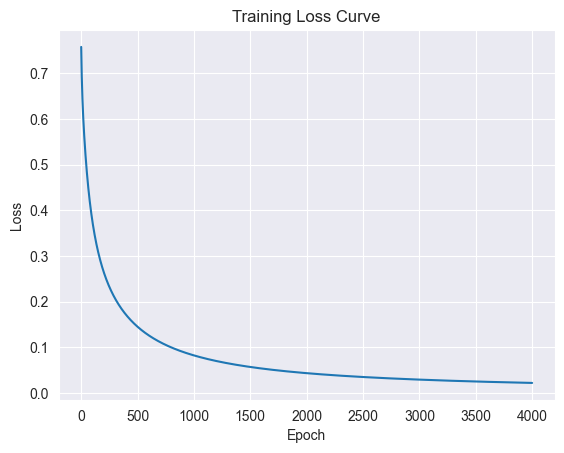

In [11]:
plot_loss(loss_values)

In [12]:
# Test the model on new data
test_input = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
test_output = model(test_input)
print(test_output)


tensor([[2.4747e-05],
        [2.5297e-02],
        [2.5297e-02],
        [9.6456e-01]], grad_fn=<SigmoidBackward0>)


In [13]:
output = (test_output > 0.5).float()

In [14]:
print(output)

tensor([[0.],
        [0.],
        [0.],
        [1.]])


In [15]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)


# 2. Create model save path 
MODEL_NAME = "01_pytorch_perceptron.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_perceptron.pth


In [16]:
# 1+ hidden layers/ 10-512 neurons/ 1+ outputs/ ReLU/sigmoid or softmax/binary crossentropy or cross entropy/ SGD  

In [17]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [18]:
from sklearn.datasets import make_circles


# Make 2000 samples 
n_samples = 2000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.05, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

In [19]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [20]:
print(f"Last 5 X features:\n{X[5:]}") #Wink wink numpy slicing
print(f"\Last 5 y labels:\n{y[5:]}")

Last 5 X features:
tensor([[-0.1930,  0.7703],
        [ 1.0001, -0.3373],
        [-0.1127, -0.8118],
        ...,
        [ 0.6222, -0.7182],
        [-0.7904,  0.1368],
        [ 0.5993,  0.5590]])
\Last 5 y labels:
tensor([1., 0., 1.,  ..., 0., 1., 1.])


<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:2: SyntaxWarning: invalid escape sequence '\L'
C:\Users\Alexandra\AppData\Local\Temp\ipykernel_18376\212639444.py:2: SyntaxWarning: invalid escape sequence '\L'
  print(f"\Last 5 y labels:\n{y[5:]}")


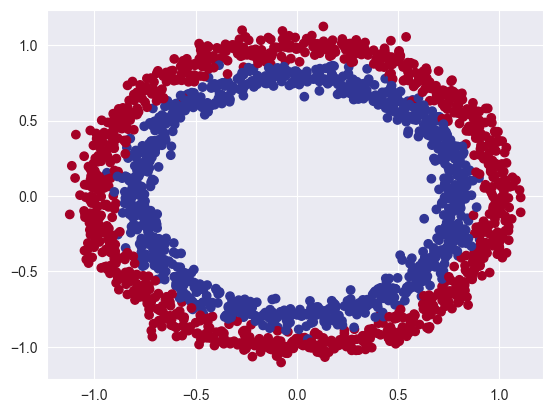

In [21]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu);

In [22]:
'''
Ex 1
Analyse the data: print the shape of our toy dataset
What's the second dimension on X?
Print some values of the toy dataset
'''
print(X.shape)
#sec dim of x : 2
print(y.shape)
print(f"Sample 1 -> X: {X[0]}, y: {y[0]}")
print(f"Sample 2 -> X: {X[1]}, y: {y[1]}")

torch.Size([2000, 2])
torch.Size([2000])
Sample 1 -> X: tensor([ 0.4452, -0.5584]), y: 1.0
Sample 2 -> X: tensor([-0.6263,  0.8151]), y: 0.0


In [23]:
'''
In the next step, we need to prepare the data to be compatible with PyTorch and for modelling. To achieve this, we have two tasks to complete:

Convert our data from NumPy arrays to PyTorch tensors as PyTorch works more efficiently with tensors. Create a split between the training and testing sets. The model is trained on the training set to learn the relationships between X and y. Afterward, the model's learned patterns are evaluated on the test dataset.
'''

from sklearn.model_selection import train_test_split

# X_train = torch.from_numpy(X).type(torch.float)
# y_test = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42) 
y_test = y_test.unsqueeze(1)
y_train = y_train.unsqueeze(1)


In [24]:
'''
Ex 3 Build a model similar to the perceptron with 2 linear layers (no activation function) Please be mindfull of your model names (distinct names) If capable move your model to the gpu
'''

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
class Perceptron2Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4) 
        self.layer2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return x

model_perceptron = Perceptron2Layer().to(device)
print(model_perceptron)



Using device: cpu
Perceptron2Layer(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (layer2): Linear(in_features=4, out_features=1, bias=True)
)


In [25]:
'''
LOSS FUNCTION AND OPTIMIZER 
1. SGD op-> classification/regression -> torch.optim.SGD()
2. Adam op-> classification/regression -> torch.optim.Adam()
3. Binary Cross Entropy loss -> binary classification -> torch.nn.BCEWithLogitsLoss()/ torch.nn.BCELoss()
4. Cross Entropy loss -> multi-class classification -> torch.nn.CrossEntropyLoss()
5. Mean abs error MAE or L1 loss-> regression -> torch.nn.L1Loss()
6. Mean squared error MSE or L2 loss-> regression -> torch.nn.MSELoss()
'''

'\nLOSS FUNCTION AND OPTIMIZER \n1. SGD op-> classification/regression -> torch.optim.SGD()\n2. Adam op-> classification/regression -> torch.optim.Adam()\n3. Binary Cross Entropy loss -> binary classification -> torch.nn.BCEWithLogitsLoss()/ torch.nn.BCELoss()\n4. Cross Entropy loss -> multi-class classification -> torch.nn.CrossEntropyLoss()\n5. Mean abs error MAE or L1 loss-> regression -> torch.nn.L1Loss()\n6. Mean squared error MSE or L2 loss-> regression -> torch.nn.MSELoss()\n'

In [26]:
'''
For the optimizer we'll use torch.optim.SGD() to optimize the model parameters with learning rate 0.1.
Ex 4 Create the recommended loss_fn and optimizer
'''
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_perceptron.parameters(), lr=0.1)

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    model.eval()
    
    # Move to CPU (important if using GPU)
    X = X.cpu()
    y = y.cpu()
    
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    
    with torch.no_grad():
        logits = model(grid)
        preds = torch.round(torch.sigmoid(logits))
    
    preds = preds.reshape(xx.shape)
    
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
    plt.show()

Accuracy: 51.75%


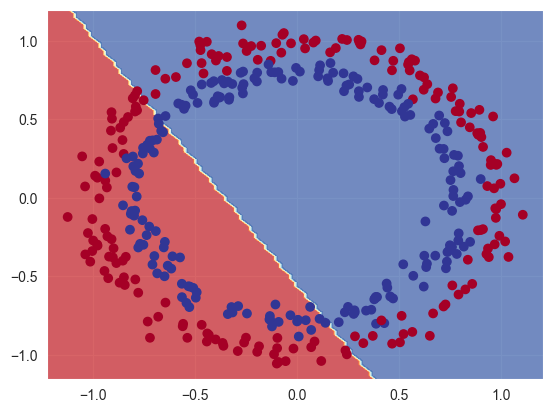

In [28]:
# 3 Evaluate Model
#from utils import plot_decision_boundary
model_perceptron.eval()
logits=model_perceptron(X_test)
preds=torch.round(torch.sigmoid(logits))
acc=accuracy_fn(y_test,preds)
print(f"Accuracy: {acc:.2f}%")
plot_decision_boundary(model_perceptron, X_test, y_test)


In [29]:
'''
# Ex 5 Build the training loop
# Every 10 epochs rint the loss and the accuracy and save them in a loss_curve, acc_curve
# Also plot them
'''

num_epochs = 4000
loss_curve = []
acc_curve = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    y_pred = model_perceptron(X_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()
    # Print the loss every 100 epochs
    loss_curve.append(loss.item())
    if (epoch + 1) % 100 == 0:
        preds=torch.round(torch.sigmoid(y_pred))
        acc=accuracy_fn(y_train,y_pred)
        acc_curve.append(acc)
       # print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

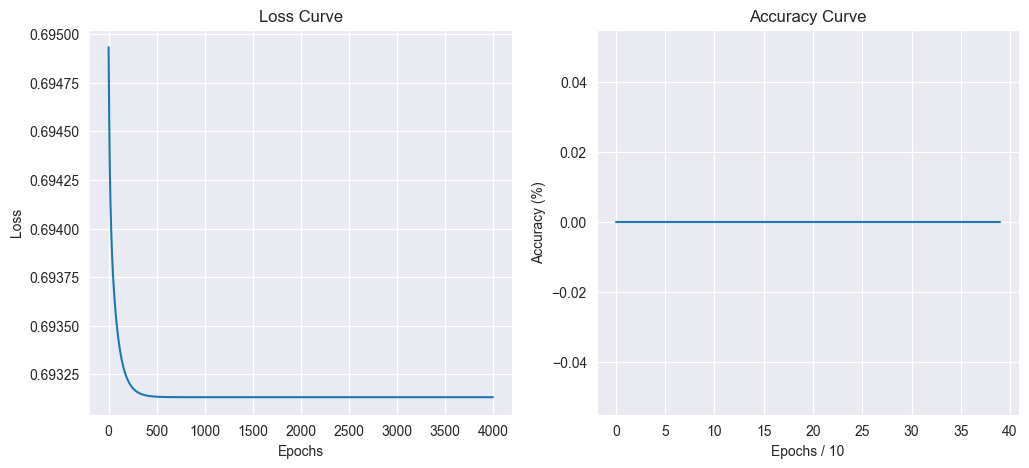

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loss_curve)
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(acc_curve)
plt.title('Accuracy Curve')
plt.xlabel('Epochs / 10')
plt.ylabel('Accuracy (%)')
plt.show()

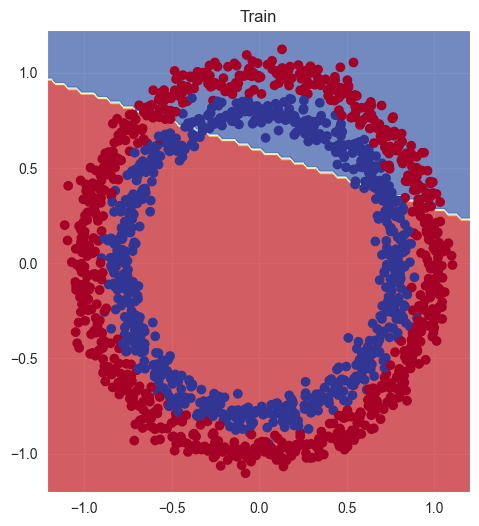

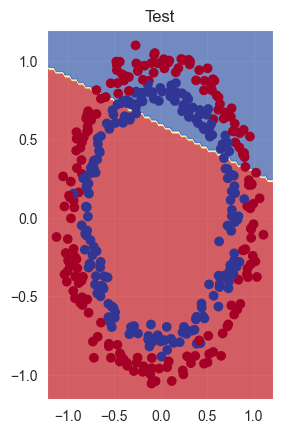

In [31]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_perceptron, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_perceptron, X_test, y_test)

In [32]:
'''
IMPROVE
1. add layers -> increases learning capability (deeper)
2. add hidden units -> units/layer = learning capability (wider)
3. fitting for longer = more epochs -> learn more 
4. change activation fct -> for example use non-linear activation function
5. change learning rate ->  too much and the model overcorrects, too little and it doesn't learn enough.
6. change loss fct -> bce won't work with multi-class classification
'''

"\nIMPROVE\n1. add layers -> increases learning capability (deeper)\n2. add hidden units -> units/layer = learning capability (wider)\n3. fitting for longer = more epochs -> learn more \n4. change activation fct -> for example use non-linear activation function\n5. change learning rate ->  too much and the model overcorrects, too little and it doesn't learn enough.\n6. change loss fct -> bce won't work with multi-class classification\n"

In [33]:
# Create a toy tensor (similar to the data going into our model(s))
input_dummy = torch.arange(-10, 10, 1, dtype=torch.float32)
input_dummy

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

In [34]:
def relu(x):
  return torch.maximum(torch.tensor(0), x) # inputs must be tensors

# Pass toy tensor through ReLU function
relu(input_dummy)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

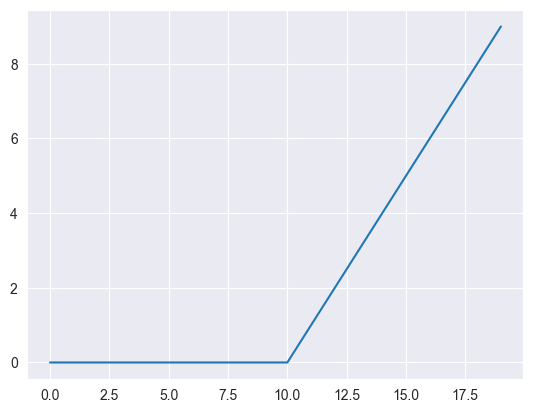

In [35]:
plt.plot(relu(input_dummy))

In [36]:
# Ex 6 Recreate the model with some none linear activation functions
class Perceptron2LayerNew(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4) 
        self.act1=nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        
    def forward(self, x):
        x = self.layer1(x)
        x=self.act1(x)
        x = self.layer2(x)
        return x

model_perceptron_new = Perceptron2LayerNew().to(device)
print(model_perceptron_new)

Perceptron2LayerNew(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (act1): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
)


In [37]:
# Ex 7 Recreate the optimizer and training loop
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_perceptron_new.parameters(),lr=0.1)
                            
num_epochs = 4000
loss_curve = []
acc_curve = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    y_pred = model_perceptron_new(X_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()
    # Print the loss every 100 epochs
    loss_curve.append(loss.item())
    if (epoch + 1) % 100 == 0:
        preds=torch.round(torch.sigmoid(y_pred))
        acc=accuracy_fn(y_train,preds)
        acc_curve.append(acc)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/4000], Loss: 0.6910
Epoch [200/4000], Loss: 0.6893
Epoch [300/4000], Loss: 0.6878
Epoch [400/4000], Loss: 0.6864
Epoch [500/4000], Loss: 0.6848
Epoch [600/4000], Loss: 0.6832
Epoch [700/4000], Loss: 0.6815
Epoch [800/4000], Loss: 0.6796
Epoch [900/4000], Loss: 0.6774
Epoch [1000/4000], Loss: 0.6752
Epoch [1100/4000], Loss: 0.6729
Epoch [1200/4000], Loss: 0.6706
Epoch [1300/4000], Loss: 0.6684
Epoch [1400/4000], Loss: 0.6663
Epoch [1500/4000], Loss: 0.6642
Epoch [1600/4000], Loss: 0.6620
Epoch [1700/4000], Loss: 0.6598
Epoch [1800/4000], Loss: 0.6576
Epoch [1900/4000], Loss: 0.6552
Epoch [2000/4000], Loss: 0.6529
Epoch [2100/4000], Loss: 0.6506
Epoch [2200/4000], Loss: 0.6484
Epoch [2300/4000], Loss: 0.6461
Epoch [2400/4000], Loss: 0.6435
Epoch [2500/4000], Loss: 0.6410
Epoch [2600/4000], Loss: 0.6386
Epoch [2700/4000], Loss: 0.6362
Epoch [2800/4000], Loss: 0.6340
Epoch [2900/4000], Loss: 0.6318
Epoch [3000/4000], Loss: 0.6295
Epoch [3100/4000], Loss: 0.6267
Epoch [3200/4000]

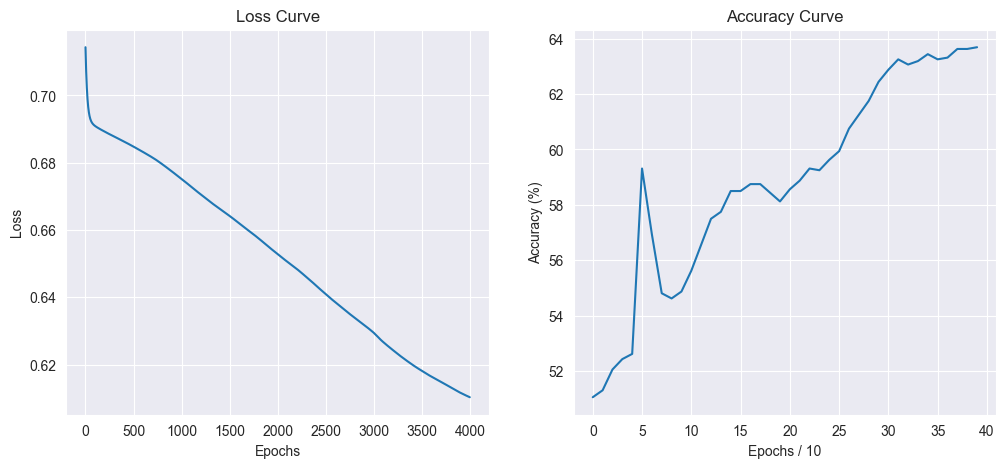

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loss_curve)
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(acc_curve)
plt.title('Accuracy Curve')
plt.xlabel('Epochs / 10')
plt.ylabel('Accuracy (%)')
plt.show()

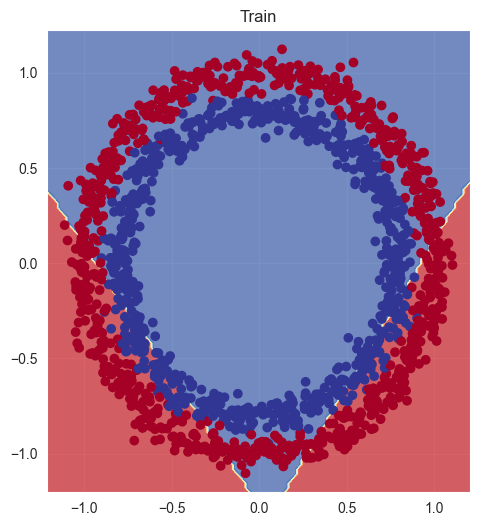

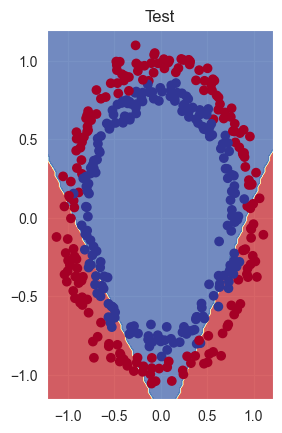

In [39]:
# Ex 8 Evaluate vizual
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_perceptron_new, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_perceptron_new, X_test, y_test)

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


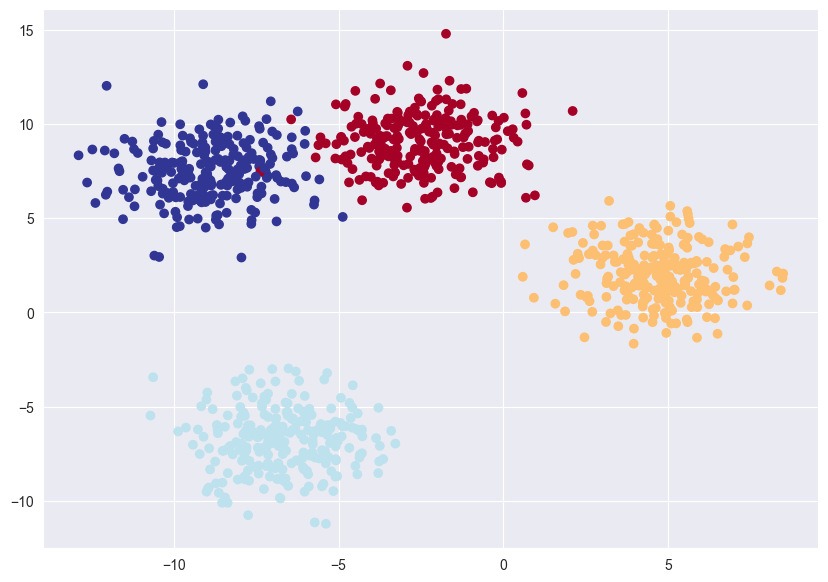

In [40]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels 
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [41]:
# Ex 9 (For grade 10): Create a pytorch flow to do multi class classification as instructed in the previos examples

# Tip since the data presents itself as a having liniar relationships no relu/sigmoid activation are required.


In [42]:
class MultiClassModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)

model_blob = MultiClassModel(NUM_FEATURES, NUM_CLASSES)
print(model_blob)

MultiClassModel(
  (linear): Linear(in_features=2, out_features=4, bias=True)
)


In [43]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_blob.parameters(), lr=0.1)

In [44]:
num_epochs = 1000
loss_curve = []
acc_curve = []

for epoch in range(num_epochs):
    model_blob.train()
    logits = model_blob(X_blob_train)
    loss = loss_fn(logits, y_blob_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_curve.append(loss.item())
    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            acc = (preds == y_blob_train).float().mean().item() * 100
            acc_curve.append(acc)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {acc:.2f}%")

Epoch [50/1000], Loss: 0.0921, Accuracy: 99.00%
Epoch [100/1000], Loss: 0.0667, Accuracy: 99.00%
Epoch [150/1000], Loss: 0.0561, Accuracy: 99.00%
Epoch [200/1000], Loss: 0.0501, Accuracy: 99.00%
Epoch [250/1000], Loss: 0.0462, Accuracy: 99.00%
Epoch [300/1000], Loss: 0.0434, Accuracy: 99.00%
Epoch [350/1000], Loss: 0.0413, Accuracy: 99.00%
Epoch [400/1000], Loss: 0.0396, Accuracy: 99.00%
Epoch [450/1000], Loss: 0.0383, Accuracy: 99.00%
Epoch [500/1000], Loss: 0.0372, Accuracy: 99.00%
Epoch [550/1000], Loss: 0.0362, Accuracy: 99.00%
Epoch [600/1000], Loss: 0.0354, Accuracy: 99.00%
Epoch [650/1000], Loss: 0.0348, Accuracy: 99.00%
Epoch [700/1000], Loss: 0.0342, Accuracy: 99.00%
Epoch [750/1000], Loss: 0.0336, Accuracy: 99.00%
Epoch [800/1000], Loss: 0.0331, Accuracy: 99.00%
Epoch [850/1000], Loss: 0.0327, Accuracy: 99.00%
Epoch [900/1000], Loss: 0.0323, Accuracy: 99.00%
Epoch [950/1000], Loss: 0.0320, Accuracy: 99.00%
Epoch [1000/1000], Loss: 0.0317, Accuracy: 99.00%


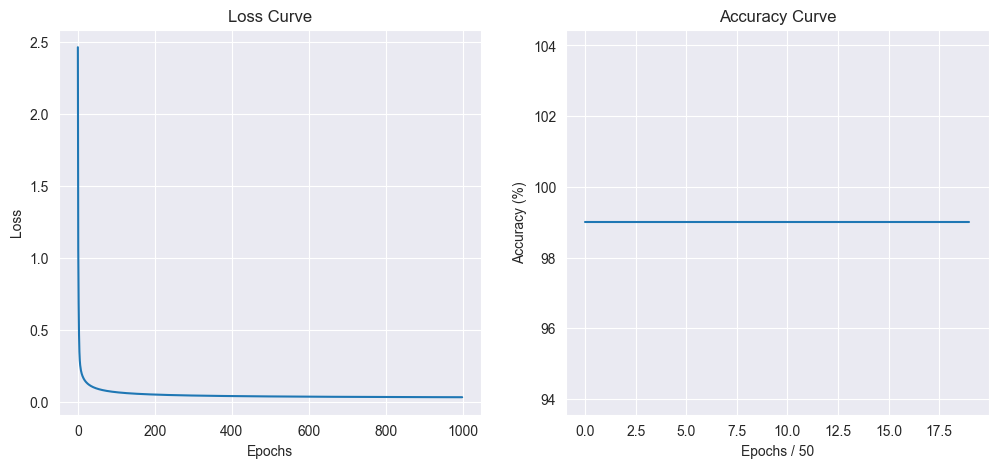

In [45]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loss_curve)
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(acc_curve)
plt.title('Accuracy Curve')
plt.xlabel('Epochs / 50')
plt.ylabel('Accuracy (%)')
plt.show()

In [46]:
def plot_decision_boundary_multiclass(model, X, y):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 200),
                            torch.linspace(y_min, y_max, 200))
    
    grid = torch.cat([xx.reshape(-1,1), yy.reshape(-1,1)], dim=1)
    
    with torch.no_grad():
        logits = model(grid)
        preds = torch.argmax(logits, dim=1).reshape(xx.shape)
    
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k')
    plt.show()

C:\Users\Alexandra\PycharmProjects\aiclasses\.venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


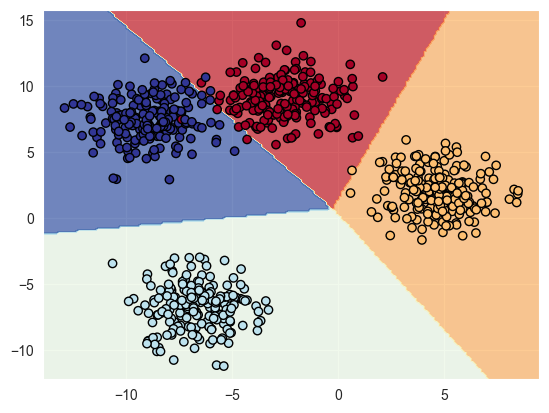

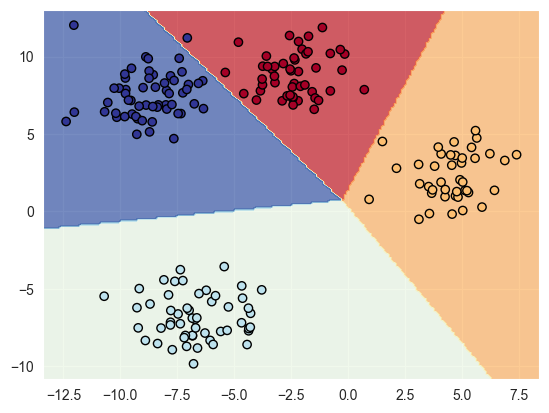

In [47]:
plot_decision_boundary_multiclass(model_blob, X_blob_train, y_blob_train)
plot_decision_boundary_multiclass(model_blob, X_blob_test, y_blob_test)